In [1]:
HOME_DIR = '/Users/askhaled/Documents/MegaMouse/'
DESTINATION = 'outputs'

In [2]:
# ## Libraries

#libs
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn import linear_model
import pandas as pd
import numpy as np
import scikitplot as skplt
import matplotlib.pyplot as plt
from sklearn import metrics

from sklearn.pipeline import Pipeline
from sklearn import preprocessing as pp
import seaborn as sns

#import fastparquet

from sklearn.feature_selection import SelectFromModel

from joblib import dump, load

In [3]:
#%pip install conda-forge::tensorflow

In [4]:
# cnn model
#import tensorflow as tf
#from tensorflow import keras
import keras
from numpy import mean
from numpy import std
from numpy import dstack
from pandas import read_csv
from matplotlib import pyplot
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, Flatten, Dropout, Activation
#from keras.layers.convolutional import Conv1D, ZeroPadding1D, MaxPooling1D
from keras.layers import Conv2D, MaxPool2D, Conv1D, ZeroPadding1D, MaxPooling1D
from keras.utils import to_categorical
#from keras.layers.core import Reshape 
from keras.layers import Reshape 
from keras import activations

In [5]:
%matplotlib inline

In [6]:
# ## Invivo Data

# load data
mega_mouse_ML = pd.read_csv('/Users/askhaled/Documents/MegaMouse/mega_mouse_pixels2_20240701.csv')

# drop columns we cannot measure or that are redundant
cols_2_drop_mm = ['Mice','Temp', 'SatPower(uT)', 'SatTime(ms)']
mega_mouse_ML = mega_mouse_ML.drop(cols_2_drop_mm, axis = 1)

print(mega_mouse_ML.shape)

(6003, 46)


In [7]:
# Scaling CEST curves for each row
mega_mouse_ML_scaled = mega_mouse_ML
subset = mega_mouse_ML_scaled.loc[:, '-10':'10'].copy()
# for i in range(len(mega_mouse_ML_scaled)):    
#    df1_norm = subset.iloc[i]
#    df1_norm = sklearn.preprocessing.minmax_scale(df1_norm, feature_range=(0, 1), axis=0, copy=True)
#    subset.iloc[i] = df1_norm

In [8]:
mega_mouse_ML_scaled.loc[:, '-10':'10'] = subset;

In [9]:

mega_mouse_ML_scaled.iloc[600];


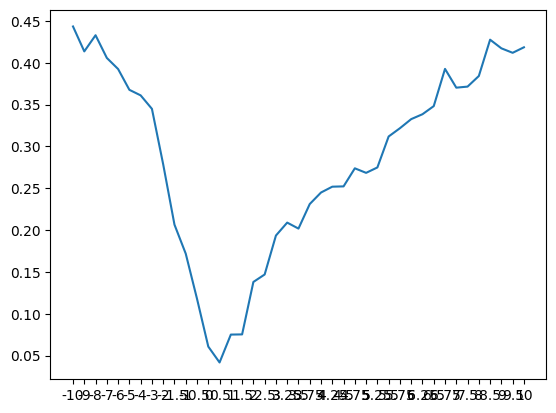

In [10]:
subset = mega_mouse_ML_scaled.loc[:, '-10':'10']
plt.plot(subset.iloc[30])
plt.show()

In [11]:
# Check if there are any NaN values in the entire DataFrame
has_nan = mega_mouse_ML_scaled.isnull().any().any()

# or equivalently
has_nan = mega_mouse_ML_scaled.isna().any().any()

print(f"DataFrame contains NaN: {has_nan}")

DataFrame contains NaN: False


In [12]:
mega_mouse_CEST = mega_mouse_ML_scaled.loc[:, '-10':'10'].copy()
mega_mouse_pH = mega_mouse_ML_scaled.loc[:, 'pH'].copy()

In [13]:
mega_mouse_CEST.head()

,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1.5,...,6.25,6.5,6.75,7,7.5,8,8.5,9,9.5,10
0,0.363055,0.347639,0.323526,0.310382,0.301379,0.295964,0.367032,0.319545,0.114881,0.180046,...,0.299337,0.296639,0.290854,0.293595,0.309636,0.325996,0.346403,0.352872,0.388528,0.448513
1,0.363055,0.347639,0.323526,0.310382,0.301379,0.295964,0.367032,0.319545,0.114881,0.180046,...,0.299337,0.296639,0.290854,0.293595,0.309636,0.325996,0.346403,0.352872,0.388528,0.448513
2,0.440031,0.413064,0.414271,0.384911,0.377109,0.363356,0.320271,0.291704,0.227771,0.194851,...,0.356508,0.358590,0.366292,0.375612,0.409327,0.427694,0.420487,0.424310,0.433796,0.442254
3,0.440031,0.413064,0.414271,0.384911,0.377109,0.363356,0.320271,0.291704,0.227771,0.194851,...,0.356508,0.358590,0.366292,0.375612,0.409327,0.427694,0.420487,0.424310,0.433796,0.442254
4,0.466261,0.455792,0.442671,0.443345,0.434089,0.399077,0.387761,0.370151,0.317615,0.306089,...,0.303109,0.319266,0.335497,0.345110,0.376581,0.387007,0.385762,0.416087,0.438219,0.421897


In [14]:
mega_mouse_pH.head()

0    7.592699
1    7.592699
2    6.573686
3    6.573686
4    6.526086
Name: pH, dtype: float64

In [15]:
len(mega_mouse_pH)

6003

In [16]:
mega_mouse_ML_scaled_pH_threshold = mega_mouse_ML_scaled[(mega_mouse_ML_scaled['pH'] >= 6.2) & (mega_mouse_ML_scaled['pH'] <= 7.6)]

In [17]:
mega_mouse_CEST = mega_mouse_ML_scaled_pH_threshold.loc[:, '-10':'10'].copy()
mega_mouse_pH = mega_mouse_ML_scaled_pH_threshold.loc[:, 'pH'].copy()

In [18]:
len(mega_mouse_pH)

4129

In [19]:
# ## Functions

# ### CNN Model

def build_model(learning_rate=0.01):
    keras.backend.clear_session()
    
    n_offset = 41
    n_outputs = 1
    print (n_outputs)
    n_features = 1
    
    model = Sequential()
    
#     1st
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', name='conv_1', input_shape=(n_offset,n_features)))
    model.add(MaxPooling1D(pool_size=2))  
              
#     2nd
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same',name='conv_2'))
    model.add(MaxPooling1D(pool_size=2))

#     3rd
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same',name='conv_3'))
    model.add(MaxPooling1D(pool_size=2))
    
#     4th
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same',name='conv_4'))
    model.add(MaxPooling1D(pool_size=2))
               
    model.add(Flatten())
    model.add(Dropout(0.2))
    
    model.add(Dense(64, activation='relu', name='dense'))

    
    #model.add(Dense(n_outputs, activation='softmax', name='output'))   
    #sgd = keras.optimizers.sgd(lr=0.001)
    #model.compile(loss = "categorical_crossentropy", metrics=['accuracy'], optimizer = sgd)
    model.add(Dense(n_outputs, name='output'))  
    
    opt = Adam(learning_rate=learning_rate) # <- set optimizer
    
    model.compile(optimizer=opt, loss='mae')
          
    model.summary()
    return model

In [20]:
def evaluate_model(X, y):
    verbose, epochs, batch_size = 1, 200, 32
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
    model = build_model()
    history = model.fit(X, y, validation_split=0.2,
                    epochs=epochs, batch_size=batch_size, verbose=verbose,
                       callbacks=[early_stop]) 

    model.save_weights(HOME_DIR + DESTINATION +'/model_weights2_20240904.h5')
        
    #save_history(history, HOME_DIR + DESTINATION +'history_20240703.bin')
    return model

In [21]:
# Train with CEST signals only

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# X and y are your features and labels
X = mega_mouse_CEST;
y = mega_mouse_pH;

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to numpy arrays
X_train = np.array(X_train_scaled)
y_train = np.array(y_train)
X_test = np.array(X_test_scaled)
y_test = np.array(y_test)

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (2890, 41)
Training labels shape: (2890,)
Testing data shape: (1239, 41)
Testing labels shape: (1239,)


In [22]:
# # CNN training
import time

start_time = time.time()

model = evaluate_model(X_train, y_train)

print (time.time() - start_time, "seconds")

1
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv_1 (Conv1D)             (None, 41, 64)            256       
                                                                 
 max_pooling1d (MaxPooling1D  (None, 20, 64)           0         
 )                                                               
                                                                 
 conv_2 (Conv1D)             (None, 20, 64)            12352     
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 10, 64)           0         
 1D)                                                             
                                                                 
 conv_3 (Conv1D)             (None, 10, 64)            12352     
                                                                 
 max_pooling1d_2 (MaxPooling  (None, 5, 64)           

In [23]:
from sklearn.model_selection import RandomizedSearchCV
from tensorflow.keras.wrappers.scikit_learn import KerasRegressor

model = KerasRegressor(build_fn=build_model, epochs=50, batch_size=32)

param_dist = {'learning_rate': [0.001, 0.01, 0.1],
              'batch_size': [16, 32, 64, 128]}

#param_dist = {'learning_rate': [0.001],
#              'batch_size': [16]}

random_search = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=12, cv=3)
random_search.fit(X_train, y_train)


1
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv_1 (Conv1D)             (None, 41, 64)            256       
                                                                 
 max_pooling1d (MaxPooling1D  (None, 20, 64)           0         
 )                                                               
                                                                 
 conv_2 (Conv1D)             (None, 20, 64)            12352     
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 10, 64)           0         
 1D)                                                             
                                                                 
 conv_3 (Conv1D)             (None, 10, 64)            12352     
                                                                 
 max_pooling1d_2 (MaxPooling  (None, 5, 64)           

C:\Users\askhaled\AppData\Local\Temp\ipykernel_648\3556463553.py:4: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  model = KerasRegressor(build_fn=build_model, epochs=50, batch_size=32)


121/121 [==============================] - 1s 4ms/step - loss: 1.7878
Epoch 2/50
121/121 [==============================] - 1s 5ms/step - loss: 0.5883
Epoch 3/50
121/121 [==============================] - 0s 4ms/step - loss: 0.4937
Epoch 4/50
121/121 [==============================] - 0s 4ms/step - loss: 0.4555
Epoch 5/50
121/121 [==============================] - 0s 4ms/step - loss: 0.4881
Epoch 6/50
121/121 [==============================] - 1s 5ms/step - loss: 0.4212
Epoch 7/50
121/121 [==============================] - 1s 4ms/step - loss: 0.4154
Epoch 8/50
121/121 [==============================] - 1s 4ms/step - loss: 0.4090
Epoch 9/50
121/121 [==============================] - 0s 4ms/step - loss: 0.3899
Epoch 10/50
121/121 [==============================] - 1s 4ms/step - loss: 0.3889
Epoch 11/50
121/121 [==============================] - 0s 4ms/step - loss: 0.3916
Epoch 12/50
121/121 [==============================] - 1s 4ms/step - loss: 0.3828
Epoch 13/50
121/121 [===============

RandomizedSearchCV(cv=3,
                   estimator=<keras.wrappers.scikit_learn.KerasRegressor object at 0x0000024FBD495030>,
                   n_iter=12,
                   param_distributions={'batch_size': [16, 32, 64, 128],
                                        'learning_rate': [0.001, 0.01, 0.1]})

In [24]:
import pandas as pd

results = pd.DataFrame(random_search.cv_results_)
print(results)

    mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0       25.270044      0.100548         0.321748        0.008093   
1       25.292580      1.534184         0.332279        0.019598   
2       24.624256      0.374725         0.367593        0.013596   
3       19.403983      0.126191         0.280697        0.013605   
4       18.797230      0.035834         0.374294        0.165041   
5       21.501560      1.615772         0.260693        0.013927   
6       16.660314      0.547207         0.250787        0.008946   
7       15.722721      0.016299         0.382250        0.175348   
8       22.728331      5.797629         0.246583        0.010078   
9       14.817890      0.136092         0.261713        0.028399   
10      14.336252      0.054707         0.403488        0.190116   
11      21.592025      3.617645         0.251743        0.013486   

    param_learning_rate  param_batch_size  \
0                 0.001                16   
1                 0.010  

In [25]:
best_model = model

In [26]:
best_model = random_search.best_estimator_
test_score = best_model.score(X_test, y_test)
print("Test set score:", test_score)

78/78 [==============================] - 0s 2ms/step - loss: 0.1185
Test set score: -0.11851374804973602


In [27]:
best_model = random_search.best_estimator_
train_score = best_model.score(X_train, y_train)
print("Train set score:", train_score)

181/181 [==============================] - 0s 2ms/step - loss: 0.0838
Train set score: -0.08382906019687653


In [28]:
print("Best parameters:", random_search.best_params_)

Best parameters: {'learning_rate': 0.001, 'batch_size': 16}


In [29]:
print("Best score:", random_search.best_score_)

Best score: -0.1947010705868403


78/78 [==============================] - 0s 2ms/step


Text(0.5, 1.0, 'CNN - Mega Mouse - minmaxscaler')

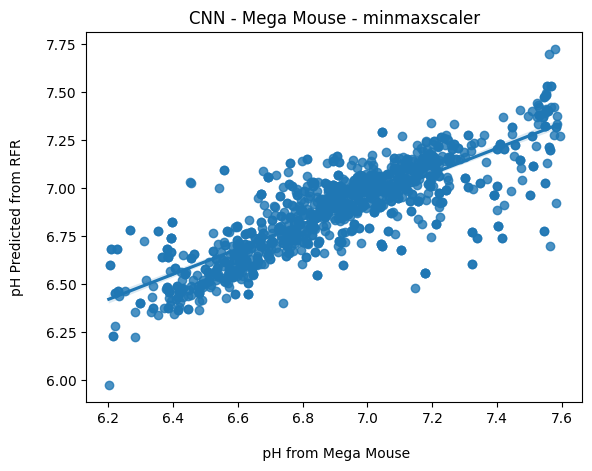

In [30]:
y_test_pred = best_model.predict(X_test)
plt.figure()
sns.regplot(x = y_test, y =  y_test_pred)
plt.xlabel('\n pH from Mega Mouse')
plt.ylabel('pH Predicted from RFR\n')
plt.title('CNN - Mega Mouse - minmaxscaler')

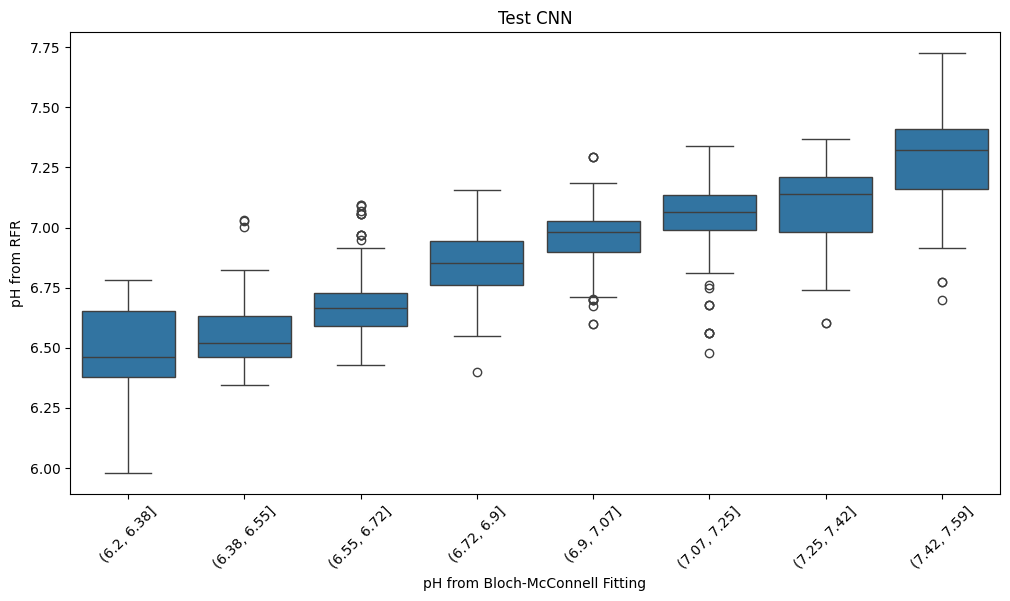

In [31]:

df = pd.DataFrame({
'value': y_test,
'prediction': y_test_pred
})

# Custom bins
#custom_bins = pd.cut(df['value'], bins=8, precision=2)
df['value_custom_bins'] = pd.cut(df['value'], bins=8, precision=2)

# Plot
plt.figure(figsize=(12, 6))
sns.boxplot(x='value_custom_bins', y='prediction', data=df, 
            color='white',
            linewidth=1.5,
            fliersize=3,
            width=0.6,
            medianprops={"color": "black"},
            capprops={"color": "black"},
            whiskerprops={"color": "black"},
            boxprops={"edgecolor": "black"},
            flierprops={"color": "black"})
plt.title('Test CNN')
plt.xlabel('pH from Bloch-McConnell Fitting')
plt.ylabel('pH from RFR')
plt.xticks(rotation=45)
plt.show()

181/181 [==============================] - 0s 2ms/step


Text(0.5, 1.0, 'CNN - Mega Mouse - minmaxscaler')

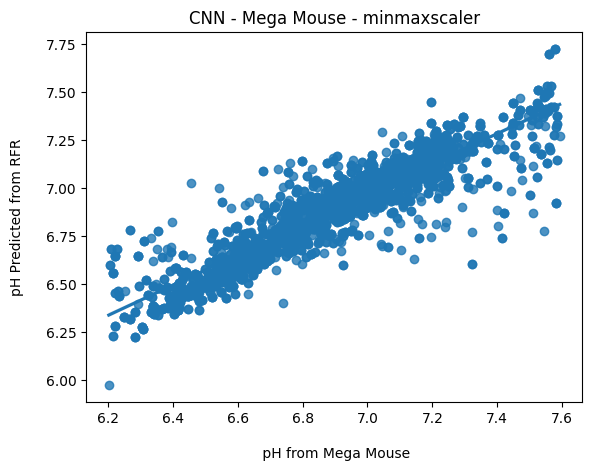

In [32]:
y_train_pred = best_model.predict(X_train)
plt.figure()
sns.regplot(x = y_train, y =  y_train_pred)
plt.xlabel('\n pH from Mega Mouse')
plt.ylabel('pH Predicted from RFR\n')
plt.title('CNN - Mega Mouse - minmaxscaler')

In [1]:
df = pd.DataFrame({
'value': y_train,
'prediction': y_train_pred
})

# Custom bins
#custom_bins = pd.cut(df['value'], bins=8, precision=2)
df['value_custom_bins'] = pd.cut(df['value'], bins=8, precision=2)

# Plot
plt.figure(figsize=(12, 6))
sns.boxplot(x='value_custom_bins', y='prediction', data=df)
#plt.title('CNN - CEST Signal only - minmaxscaler')
plt.title('Train CNN')
plt.xlabel('pH from Bloch-McConnell Fitting')
plt.ylabel('pH from RFR')
plt.xticks(rotation=45)
plt.show()

NameError: name 'pd' is not defined

In [33]:
model

In [34]:
pip install keras-visualizer


  Using cached keras_visualizer-3.2.0-py3-none-any.whl.metadata (7.6 kB)
Using cached keras_visualizer-3.2.0-py3-none-any.whl (7.1 kB)


In [35]:
# Visualize the model
from keras_visualizer import visualizer
visualizer(model, view=True)

AttributeError: 'KerasRegressor' object has no attribute 'layers'

In [ ]:
pip install graphviz pydot

In [ ]:
from tensorflow.keras.utils import plot_model
# Plot the model
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

In [ ]:
model


In [ ]:
model.save_weights(HOME_DIR + DESTINATION +'/model_weights2_20240904.h5')

In [ ]:
predictions = model.predict(X_test)
print(predictions[:5])  # Print first 5 predictions

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.axis('equal')
plt.axis('square')
#plt.plot([-100, 100], [-100, 100])
plt.show()

In [ ]:
y_test.shape

In [ ]:
predictions.shape

In [ ]:
predictions_reshaped = np.squeeze(predictions)

In [ ]:
predictions_reshaped.shape

In [ ]:
import numpy as np
from scipy import stats

corr, _ = stats.pearsonr(y_test, predictions_reshaped)
corr

In [ ]:
slope, intercept, r_value, p_value, std_err = stats.linregress(y_test, predictions_reshaped)
r_value

In [ ]:
slope

In [ ]:
r_value**2

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, predictions_reshaped)
mae = mean_absolute_error(y_test, predictions_reshaped)

print(f"MSE: {mse}")
print(f"MAE: {mae}")

In [ ]:
predictions_train = model.predict(X_train)
predictions_train_reshaped = np.squeeze(predictions_train)

mse = mean_squared_error(y_train, predictions_train_reshaped)
mae = mean_absolute_error(y_train, predictions_train_reshaped)

print(f"MSE: {mse}")
print(f"MAE: {mae}")

In [ ]:
predictions_train = model.predict(X_train_scaled)
predictions_train_reshaped = np.squeeze(predictions_train)

mse = mean_squared_error(y_train, predictions_train_reshaped)
mae = mean_absolute_error(y_train, predictions_train_reshaped)

print(f"MSE: {mse}")
print(f"MAE: {mae}")